In [149]:
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter, CoxPHFitter
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2
from lifelines.statistics import multivariate_logrank_test,logrank_test


# Cargar los datos
datos = pd.read_csv("Life_Device_A_P1.txt", sep="\t")

# Expandir las filas según el número de dispositivos
data_expanded = datos.loc[datos.index.repeat(datos['Number_of_Devices'])].reset_index(drop=True)

# Crear la variable de evento (1 = fallo, 0 = censura)
data_expanded['Evento'] = np.where(data_expanded['Status'] == 'Failed', 1, 0)




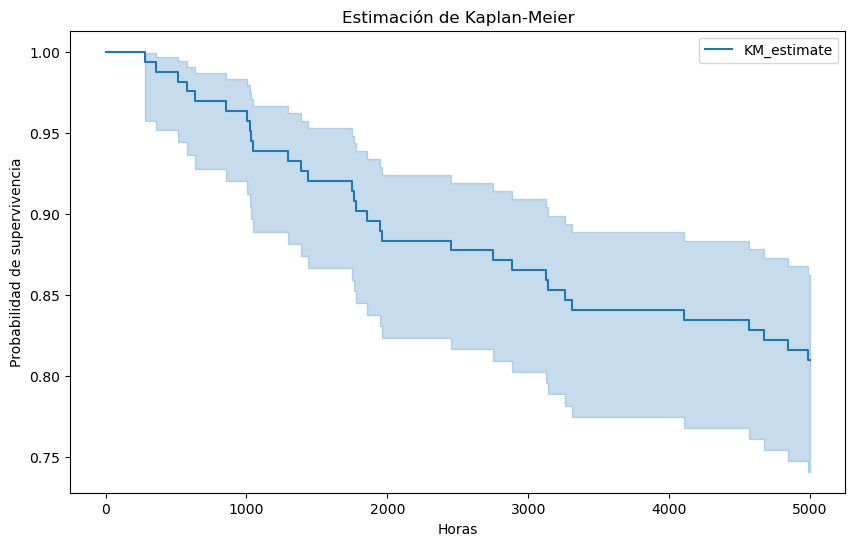

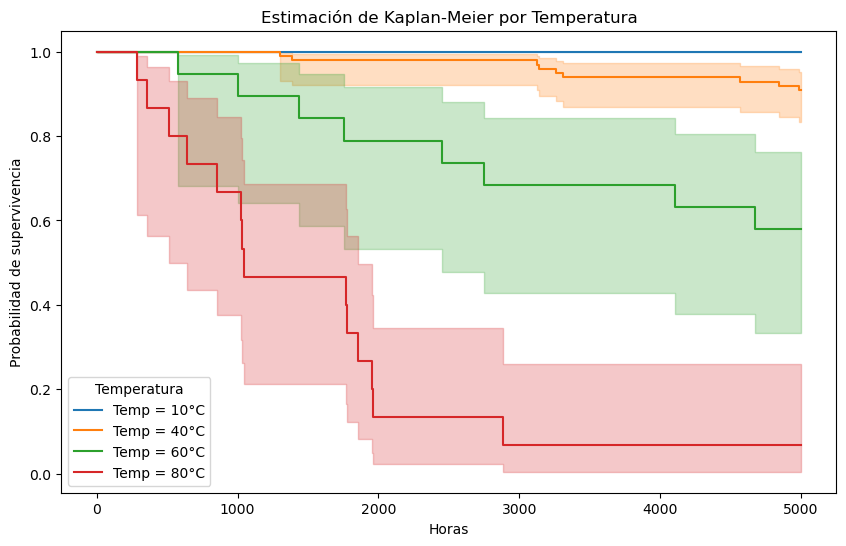

In [9]:
# Crear el objeto de Kaplan-Meier
kmf = KaplanMeierFitter()
kmf.fit(data_expanded['Hours'], event_observed=data_expanded['Evento'])

# Graficar la estimación de Kaplan-Meier
plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.xlabel("Horas")
plt.ylabel("Probabilidad de supervivencia")
plt.title("Estimación de Kaplan-Meier")
plt.show()

# Ajustar el Kaplan-Meier por temperatura
plt.figure(figsize=(10, 6))
for temp in data_expanded['Temperature'].unique():
    kmf.fit(data_expanded.loc[data_expanded['Temperature'] == temp, 'Hours'], 
            event_observed=data_expanded.loc[data_expanded['Temperature'] == temp, 'Evento'])
    kmf.plot_survival_function(label=f"Temp = {temp}°C")

plt.xlabel("Horas")
plt.ylabel("Probabilidad de supervivencia")
plt.title("Estimación de Kaplan-Meier por Temperatura")
plt.legend(title="Temperatura")
plt.show()


In [10]:

# 3. Prueba de log-rank
# Prueba log-rank multivariada (más de 2 grupos)
resultado_logrank_multi = multivariate_logrank_test(
    data_expanded['Hours'],
    data_expanded['Temperature'],
    event_observed=data_expanded['Evento']
)

# Mostrar el resumen
print(resultado_logrank_multi.summary)

   test_statistic             p    -log2(p)
0      162.925147  4.283803e-35  114.168591


In [11]:

result = logrank_test(
    data_expanded[data_expanded['Temperature'] == 10]['Hours'],
    data_expanded[data_expanded['Temperature'] != 10]['Hours'],
    event_observed_A=data_expanded[data_expanded['Temperature'] == 10]['Status'],
    event_observed_B=data_expanded[data_expanded['Temperature'] != 10]['Status']
)

print(f'Estadístico de Log-Rank: {result.test_statistic:.4f}')
print(f'Valor p: {result.p_value:.4f}')
result.p_value

Estadístico de Log-Rank: 7.9252
Valor p: 0.0049


0.004875121792498851

In [12]:
result = logrank_test(
    data_expanded[data_expanded['Temperature'] <= 50]['Hours'],
    data_expanded[data_expanded['Temperature'] > 50]['Hours'],
    event_observed_A=data_expanded[data_expanded['Temperature'] <= 50]['Status'],
    event_observed_B=data_expanded[data_expanded['Temperature'] > 50]['Status']
)

print(f'Estadístico de Log-Rank: {result.test_statistic:.4f}')
print(f'Valor p: {result.p_value:.4f}')
result.p_value

Estadístico de Log-Rank: 83.6121
Valor p: 0.0000


6.020341222317802e-20

In [92]:

# Ajustar modelo de Cox (Riesgos Proporcionales)
cph = CoxPHFitter()
cph.fit(data_expanded[['Hours', 'Evento', 'Temperature']], duration_col='Hours', event_col='Evento')

# Resumen del modelo
cph.print_summary()

# Prueba Wald
coef_T = cph.params_['Temperature']
se_T = cph.standard_errors_['Temperature']
wald_stat = (coef_T / se_T) ** 2
p_value = 1 - chi2.cdf(wald_stat, df=1)
print(f"Estadístico de Wald: {wald_stat}")
print(f"Valor-p: {p_value}")


<lifelines.CoxPHFitter: fitted with 163 total observations, 132 right-censored observations>
             duration col = 'Hours'
                event col = 'Evento'
      baseline estimation = breslow
   number of observations = 163
number of events observed = 31
   partial log-likelihood = -118.21
         time fit was run = 2025-05-05 04:59:11 UTC

---
              coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                           
Temperature   0.09       1.10       0.01             0.07             0.11                 1.07                 1.12

              cmp to    z      p   -log2(p)
covariate                                  
Temperature     0.00 8.13 <0.005      51.09
---
Concordance = 0.84
Partial AIC = 238.42
log-likelihood ratio test = 73.30 on 1 df
-log2(p) of ll-ratio test = 56.32

Estadístico de Wald: 66.15359686910031
Valor-p: 4.440892098500626e-16


In [14]:
# Modelo sin covariables (nulo)
cph_null = CoxPHFitter()
cph_null.fit(data_expanded[['Hours', 'Evento']], duration_col='Hours', event_col='Evento')

# Test de razón de verosimilitud (LRT)
lrt_stat = -2 * (cph_null.log_likelihood_ - cph.log_likelihood_)
lrt_p_value = 1 - chi2.cdf(lrt_stat, df=1)
print(f"Prueba de Razón de Verosimilitud (LRT) p-value: {lrt_p_value}")

Prueba de Razón de Verosimilitud (LRT) p-value: 0.0


In [72]:

# Ajuste de curva base
nuevo_mayor40 = pd.DataFrame({'Temperature': [50]})
nuevo_menor40 = pd.DataFrame({'Temperature': [30]})

# Obtener las curvas de supervivencia para cada escenario de temperatura
surv_mayor40 = cph.predict_survival_function(nuevo_mayor40)
surv_menor40 = cph.predict_survival_function(nuevo_menor40)



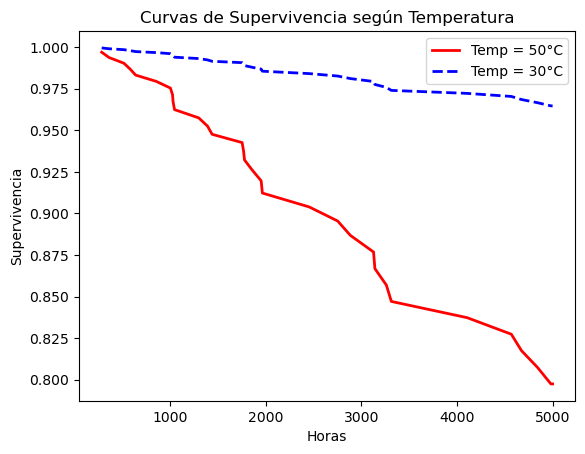

In [73]:
# Graficar las curvas de supervivencia
plt.figure()
plt.plot(surv_mayor40.index, surv_mayor40[0], label="Temp = 50°C", color="red", lw=2)
plt.plot(surv_menor40.index, surv_menor40[0], label="Temp = 30°C", color="blue", lw=2, linestyle='--')
plt.xlabel("Horas")
plt.ylabel("Supervivencia")
plt.title("Curvas de Supervivencia según Temperatura")
plt.legend()
plt.show()


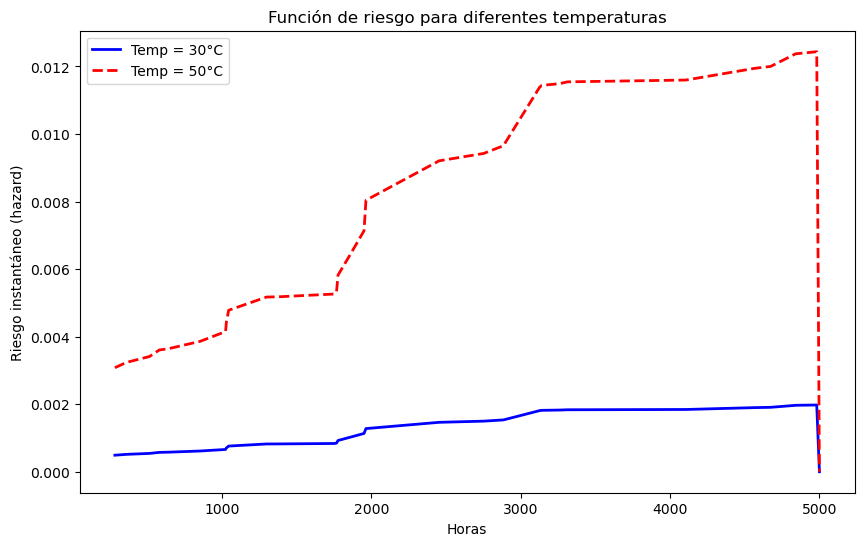

In [138]:

# Estimar la función de riesgo base (hazard)

# Estimar la función de riesgo base (hazard)
base_haz = cph.baseline_hazard_

# Función para obtener riesgo para un valor de temperatura
def obtener_hazard(temp_val):
    rr = np.exp(cph.params_['Temperature'] * (temp_val - np.mean(data_expanded["Temperature"])))
    base_vals = base_haz.values.ravel()  # Asegura vector 1D
    hazard = rr *  base_vals
    return pd.DataFrame({'time': base_haz.index, 'hazard': hazard})

# Obtener riesgos para dos temperaturas
haz_menor40 = obtener_hazard(30)
haz_mayor40 = obtener_hazard(50)

# Graficar la función de riesgo
plt.figure(figsize=(10, 6))
plt.plot(haz_menor40['time'], haz_menor40['hazard'], label="Temp = 30°C", color="blue", lw=2)
plt.plot(haz_mayor40['time'], haz_mayor40['hazard'], label="Temp = 50°C", color="red", lw=2, linestyle='--')
plt.xlabel("Horas")
plt.ylabel("Riesgo instantáneo (hazard)")
plt.title("Función de riesgo para diferentes temperaturas")
plt.legend()
plt.show()

In [140]:
s_base

,283.0,361.0,515.0,581.0,638.0,854.0,1002.0,1024.0,1030.0,1045.0,...,3127.0,3141.0,3261.0,3313.0,4106.0,4568.0,4674.0,4841.0,4982.0,5000.0
0,0.885174,0.778664,0.680256,0.589732,0.510588,0.438201,0.372362,0.31588,0.264889,0.219197,...,0.005467,0.003475,0.002205,0.001396,0.000882,0.000549,0.000342,0.000209,0.000128,0.000128


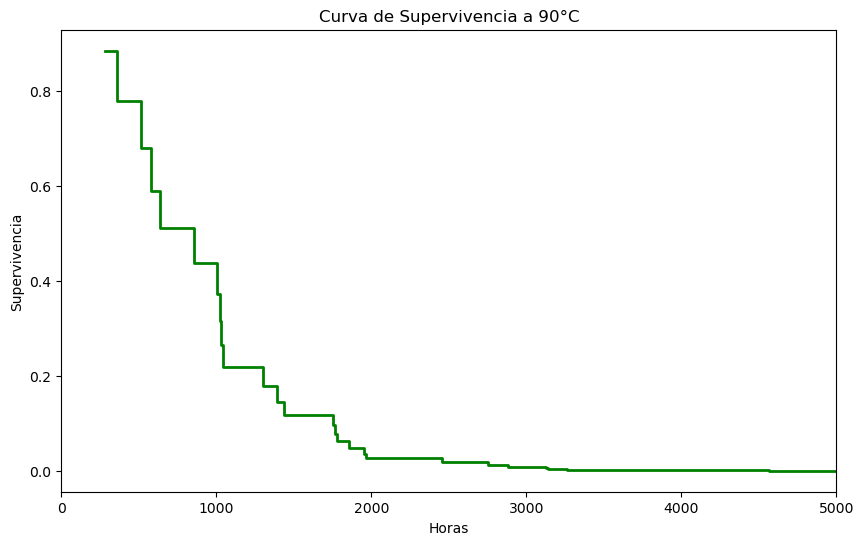

In [150]:


# Para una temperatura de 90°C
nuevo = pd.DataFrame({'Temperature': [90]})
s_base = cph.predict_survival_function(nuevo)

# Graficar la curva de supervivencia a 90°C
plt.figure(figsize=(10, 6))
plt.step(s_base.index, s_base.iloc[:, 0], where="post", color="green", lw=2)
#plt.plot(s_base.index, s_base[0], color="green", lw=2)
plt.xlim(0, 5000)
plt.title("Curva de Supervivencia a 90°C")
plt.xlabel("Horas")
plt.ylabel("Supervivencia")
plt.show()


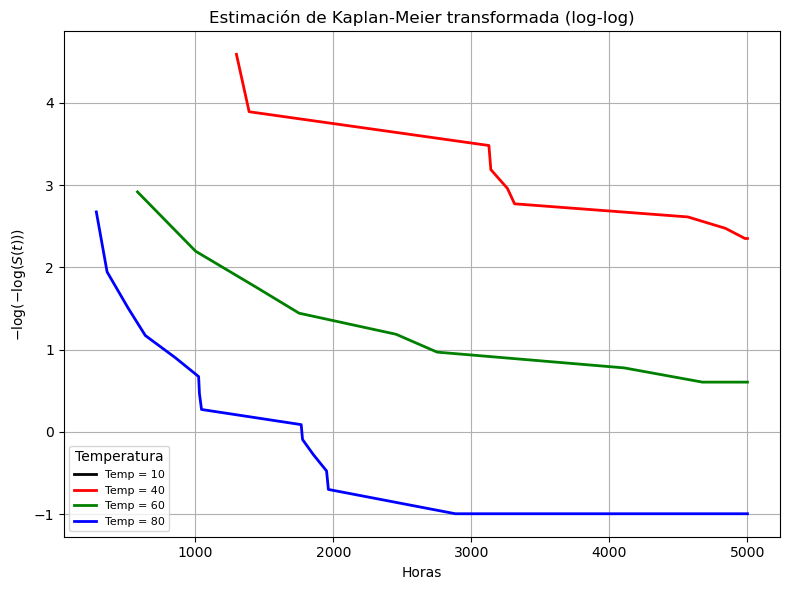

In [147]:

# Obtener niveles únicos de temperatura
temperaturas = sorted(data_expanded['Temperature'].unique())
colores = ['black', 'red', 'green', 'blue']  # Personaliza según cantidad de grupos

# Crear figura
plt.figure(figsize=(8, 6))

# Ajustar y graficar por cada grupo
for i, temp in enumerate(temperaturas):
    mask = data_expanded['Temperature'] == temp
    kmf.fit(data_expanded.loc[mask, 'Hours'], event_observed=data_expanded.loc[mask, 'Evento'], label=f'Temp = {temp}')
    
    # Transformación: -log(-log(S(t)))
    surv_probs = kmf.survival_function_.values.flatten()
    tiempos = kmf.survival_function_.index
    loglog = -np.log(-np.log(surv_probs))
    
    plt.plot(tiempos, loglog, label=f'Temp = {temp}', color=colores[i], linewidth=2)

# Personalizar gráfico
plt.xlabel("Horas")
plt.ylabel(r"$-\log(-\log(S(t)))$")
plt.title("Estimación de Kaplan-Meier transformada (log-log)")
plt.legend(title="Temperatura", loc='lower left', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()